# Bank Client Segmentation via K-Medoids Clustering

**Objective:** Implement robust clustering for mixed-type financial data (5,000 clients, 18 features) to identify distinct customer segments for targeted marketing strategies.

**Approach:** K-Medoids algorithm with distance metric comparison and validation through multiple internal cluster quality indices.

## 1. Theoretical Background: Distance Metrics for Mixed-Type Data

### 1.1 Distance Metric Properties for Financial Segmentation

Our dataset contains **mixed-type features** (5 categorical + 13 numerical), requiring careful distance metric selection:

#### Euclidean Distance (L₂)
**Formula:** $d(x,y) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$

**Pros:** 
- Computationally efficient
- Intuitive geometric interpretation
- Well-established theoretical properties

**Cons:**
- **Cannot handle categorical variables** (Job, Gender, Area, etc.)
- Sensitive to outliers (squared differences amplify extreme values)
- Curse of dimensionality in high-dimensional spaces
- Assumes continuous metric space

#### Manhattan Distance (L₁)
**Formula:** $d(x,y) = \sum_{i=1}^{n}|x_i - y_i|$

**Pros:**
- More robust than Euclidean in high dimensions
- Foundation for many composite metrics (Gower, Sørensen)

**Cons:**
- **Still requires numerical data** (incompatible with categorical features)
- Assumes axis-aligned independence (unrealistic for correlated financial variables)

#### Jaccard Distance (for categorical data)
**Formula:** $d(A,B) = 1 - \frac{|A \cap B|}{|A \cup B|}$

**Pros:**
- Excellent for binary/categorical features
- Measures set overlap semantically

**Cons:**
- **Ignores numerical magnitudes** (Income, Wealth differences lost)
- Requires binarization of numerical data

#### Gower Distance (mixed-type metric)
**Formula:** $d(x,y) = \frac{1}{p}\sum_{j=1}^{p}\delta_j(x,y)$

where:
- For numerical: $\delta_j = \frac{|x_j - y_j|}{R_j}$ (normalized Manhattan)
- For categorical: $\delta_j = 0$ if $x_j = y_j$, else $1$ (Hamming)

**Pros:**
- **Handles mixed categorical/numerical data natively**
- Automatic normalization prevents scale bias
- Equal weighting of all features (no gamma parameter tuning)
- Range-normalized to [0,1]

**Cons:**
- Computationally expensive for large datasets (O(n²) distance matrix)
- Assumes equal feature importance

### 1.2 Selection Rationale

For this dataset:
- **Categorical features** (Gender, Job, Area, CitySize, Investments) represent ~28% of features
- **Numerical features** have varying scales (Age: 19-95 vs normalized [0,1] scores)
- **Gower distance** is optimal as it:
  1. Handles mixed types without preprocessing artifacts (one-hot encoding creates sparsity)
  2. Normalizes numerical features automatically (prevents Income/Wealth dominance)
  3. Treats categorical differences uniformly (Job: Manager→Employee same as Employee→Unemployed)

## 2. Data Loading and Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import gower
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
np.random.seed(42)

In [3]:
data_path = Path("Data") / "Dataset1_BankClients.xlsx"
df = pd.read_excel(data_path)

if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

print(f"Dataset: {df.shape[0]:,} clients, {df.shape[1]} features")

Dataset: 5,000 clients, 17 features


In [4]:
categorical_cols = ['Gender', 'Job', 'Area', 'CitySize', 'Investments']
numerical_cols = ['Age', 'FamilySize', 'Income', 'Wealth', 'Debt',
                  'FinEdu', 'ESG', 'Digital', 'BankFriend',
                  'LifeStyle', 'Luxury', 'Saving']

print(f"Feature composition:")
print(f"  Categorical: {len(categorical_cols)} ({len(categorical_cols)/df.shape[1]*100:.1f}%)")
print(f"  Numerical: {len(numerical_cols)} ({len(numerical_cols)/df.shape[1]*100:.1f}%)")

Feature composition:
  Categorical: 5 (29.4%)
  Numerical: 12 (70.6%)


## 3. Distance Metric Comparison

Compare distance distributions across multiple metrics to validate Gower selection.

In [ ]:
# Sample 500 clients for computational efficiency in comparison
df_sample = df.sample(n=500, random_state=42)
df_sample_num = df_sample[numerical_cols]


# Euclidean (numerical only)
dist_euclidean = squareform(pdist(df_sample_num, metric='euclidean'))

# Manhattan (numerical only)
dist_manhattan = squareform(pdist(df_sample_num, metric='cityblock'))

# Gower (full mixed-type data)
dist_gower = gower.gower_matrix(df_sample)

Computing distance matrices for comparison (n=500 subsample)...
Distance matrices computed.


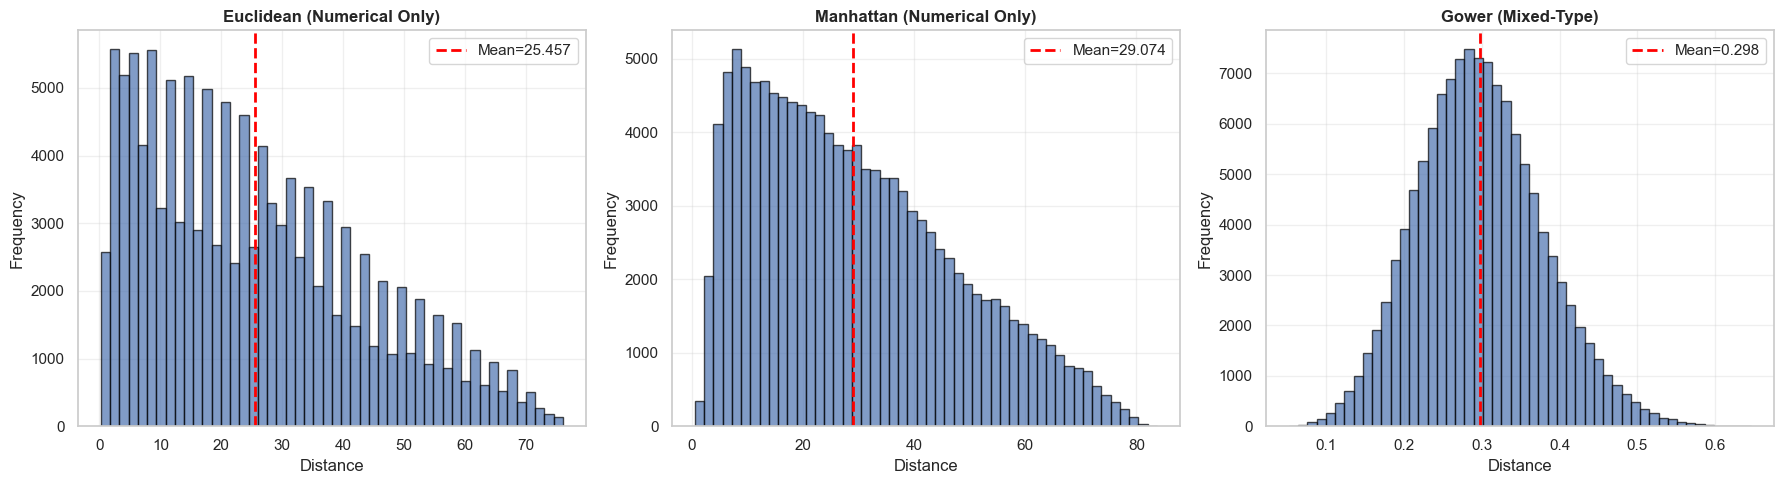


Distance Statistics:
Euclidean: mean=25.4065, std=17.7418
Manhattan: mean=29.0158, std=18.0889
Gower:     mean=0.2970, std=0.0814 [normalized to [0,1]]


In [6]:
# Visualize distance distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ('Euclidean (Numerical Only)', dist_euclidean),
    ('Manhattan (Numerical Only)', dist_manhattan),
    ('Gower (Mixed-Type)', dist_gower)
]

for ax, (title, dist_matrix) in zip(axes, metrics):
    upper_tri = dist_matrix[np.triu_indices_from(dist_matrix, k=1)]
    ax.hist(upper_tri, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(upper_tri.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean={upper_tri.mean():.3f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Distance')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDistance Statistics:")
print(f"Euclidean: mean={dist_euclidean.mean():.4f}, std={dist_euclidean.std():.4f}")
print(f"Manhattan: mean={dist_manhattan.mean():.4f}, std={dist_manhattan.std():.4f}")
print(f"Gower:     mean={dist_gower.mean():.4f}, std={dist_gower.std():.4f} [normalized to [0,1]]")

**Observation:** Gower distance is range-normalized [0,1] and incorporates categorical features (Gender, Job, Area, CitySize, Investments), providing a comprehensive similarity measure. Euclidean/Manhattan omit 28% of the feature space.

## 4. Gower Distance Matrix Computation (Full Dataset)

In [8]:
distance_matrix = gower.gower_matrix(df)

print(f"\nDistance matrix: {distance_matrix.shape}")
print(f"Range: [{distance_matrix.min():.4f}, {distance_matrix.max():.4f}]")
print(f"Mean: {distance_matrix.mean():.4f}")
print(f"Median: {np.median(distance_matrix):.4f}")


Distance matrix: (5000, 5000)
Range: [0.0000, 0.6926]
Mean: 0.2931
Median: 0.2900


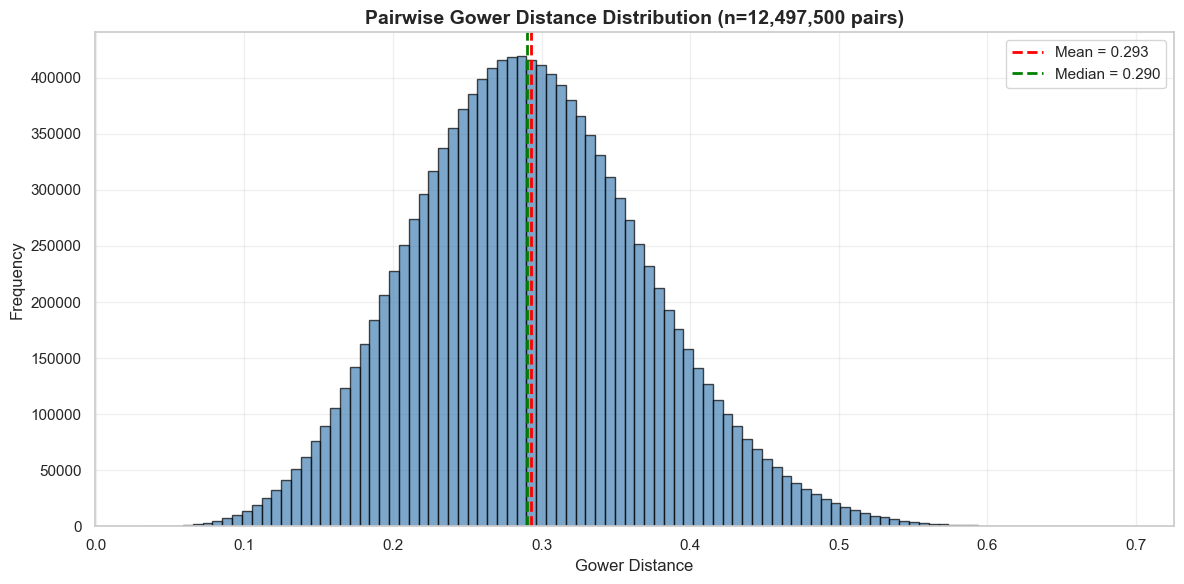

In [9]:
# Distance distribution for full dataset
upper_tri_indices = np.triu_indices_from(distance_matrix, k=1)
distances = distance_matrix[upper_tri_indices]

plt.figure(figsize=(12, 6))
plt.hist(distances, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(distances.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean = {distances.mean():.3f}')
plt.axvline(np.median(distances), color='green', linestyle='--', linewidth=2, 
            label=f'Median = {np.median(distances):.3f}')
plt.xlabel('Gower Distance', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Pairwise Gower Distance Distribution (n=12,497,500 pairs)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. K-Medoids Clustering with Optimal k Selection

### 5.1 Algorithm Rationale

**Why K-Medoids over K-Means?**
- K-Means requires computing centroids as mean vectors -> undefined for categorical features
- K-Medoids selects actual data points as cluster representatives (medoids)
- Compatible with precomputed distance matrices (Gower)
- More robust to outliers (median-based vs mean-based)

### 5.2 Cluster Validation Metrics

We employ a **voting scheme** across three complementary metrics:

1. **Silhouette Coefficient** $\in$ [-1, 1] (maximize)
   - Measures: $(b - a) / \max(a, b)$ where $a$ = avg intra-cluster distance, $b$ = avg nearest-cluster distance
   - Interpretation: Values near +1 indicate well-separated clusters

2. **Davies-Bouldin Index** $\in$ [0, ∞) (minimize)
   - Measures: Ratio of within-cluster scatter to between-cluster separation
   - Interpretation: Lower values indicate better clustering

3. **Calinski-Harabasz Index** $\in$ [0, ∞) (maximize)
   - Measures: Ratio of between-cluster variance to within-cluster variance
   - Interpretation: Higher values indicate denser, well-separated clusters

In [14]:
k_range = range(3, 7)
results = {}

print("K-Medoids clustering for k in {3, 4, 5, 6}\n")

for k in k_range:
    kmedoids = KMedoids(
        n_clusters=k,
        metric='precomputed',
        init='k-medoids++',
        max_iter=300,
        random_state=42
    )
    
    clusters = kmedoids.fit_predict(distance_matrix)
    
    results[k] = {
        'model': kmedoids,
        'clusters': clusters,
        'medoid_indices': kmedoids.medoid_indices_,
        'silhouette': silhouette_score(distance_matrix, clusters, metric='precomputed'),
        'davies_bouldin': davies_bouldin_score(distance_matrix, clusters),
        'calinski_harabasz': calinski_harabasz_score(distance_matrix, clusters),
        'inertia': kmedoids.inertia_
    }
    
    unique, counts = np.unique(clusters, return_counts=True)
    print(f"k={k}: sizes={dict(zip(unique, counts))}, "
          f"Sil={results[k]['silhouette']:.4f}, "
          f"DB={results[k]['davies_bouldin']:.4f}, "
          f"CH={results[k]['calinski_harabasz']:.2f}")

K-Medoids clustering for k in {3, 4, 5, 6}

k=3: sizes={np.int64(0): np.int64(1172), np.int64(1): np.int64(1739), np.int64(2): np.int64(2089)}, Sil=0.1624, DB=1.8803, CH=1274.68
k=4: sizes={np.int64(0): np.int64(1002), np.int64(1): np.int64(1331), np.int64(2): np.int64(1836), np.int64(3): np.int64(831)}, Sil=0.1610, DB=1.5936, CH=1502.56
k=5: sizes={np.int64(0): np.int64(1002), np.int64(1): np.int64(1303), np.int64(2): np.int64(1699), np.int64(3): np.int64(664), np.int64(4): np.int64(332)}, Sil=0.1421, DB=1.9234, CH=1226.02
k=6: sizes={np.int64(0): np.int64(1047), np.int64(1): np.int64(727), np.int64(2): np.int64(1228), np.int64(3): np.int64(634), np.int64(4): np.int64(293), np.int64(5): np.int64(1071)}, Sil=0.1184, DB=2.2296, CH=952.33


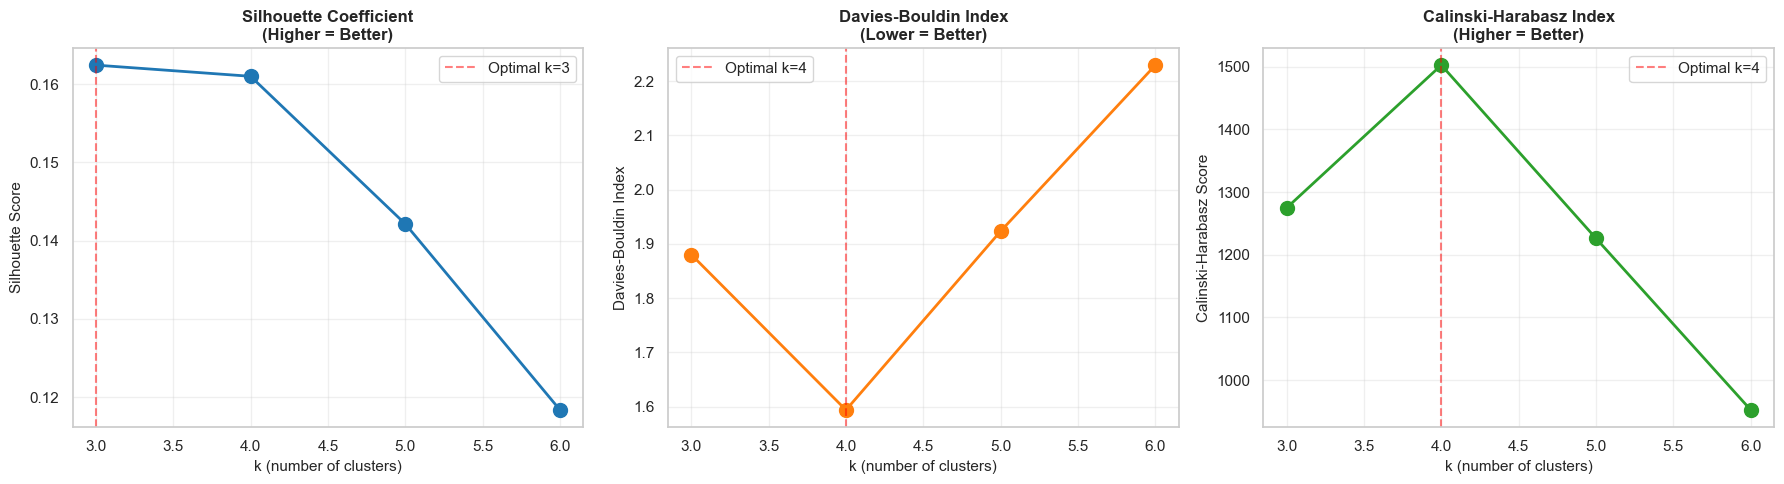

In [15]:
# Metrics visualization
summary_df = pd.DataFrame({
    'k': list(results.keys()),
    'Silhouette': [results[k]['silhouette'] for k in results.keys()],
    'Davies-Bouldin': [results[k]['davies_bouldin'] for k in results.keys()],
    'Calinski-Harabasz': [results[k]['calinski_harabasz'] for k in results.keys()]
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette
axes[0].plot(summary_df['k'], summary_df['Silhouette'], marker='o', linewidth=2, markersize=10, color='#1f77b4')
best_k_sil = summary_df.loc[summary_df['Silhouette'].idxmax(), 'k']
axes[0].axvline(best_k_sil, color='red', linestyle='--', alpha=0.5, label=f'Optimal k={int(best_k_sil)}')
axes[0].set_xlabel('k (number of clusters)', fontsize=11)
axes[0].set_ylabel('Silhouette Score', fontsize=11)
axes[0].set_title('Silhouette Coefficient\n(Higher = Better)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Davies-Bouldin
axes[1].plot(summary_df['k'], summary_df['Davies-Bouldin'], marker='o', linewidth=2, markersize=10, color='#ff7f0e')
best_k_db = summary_df.loc[summary_df['Davies-Bouldin'].idxmin(), 'k']
axes[1].axvline(best_k_db, color='red', linestyle='--', alpha=0.5, label=f'Optimal k={int(best_k_db)}')
axes[1].set_xlabel('k (number of clusters)', fontsize=11)
axes[1].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[1].set_title('Davies-Bouldin Index\n(Lower = Better)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Calinski-Harabasz
axes[2].plot(summary_df['k'], summary_df['Calinski-Harabasz'], marker='o', linewidth=2, markersize=10, color='#2ca02c')
best_k_ch = summary_df.loc[summary_df['Calinski-Harabasz'].idxmax(), 'k']
axes[2].axvline(best_k_ch, color='red', linestyle='--', alpha=0.5, label=f'Optimal k={int(best_k_ch)}')
axes[2].set_xlabel('k (number of clusters)', fontsize=11)
axes[2].set_ylabel('Calinski-Harabasz Score', fontsize=11)
axes[2].set_title('Calinski-Harabasz Index\n(Higher = Better)', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Voting scheme for optimal k
votes = {}
votes[int(best_k_sil)] = votes.get(int(best_k_sil), 0) + 1
votes[int(best_k_db)] = votes.get(int(best_k_db), 0) + 1
votes[int(best_k_ch)] = votes.get(int(best_k_ch), 0) + 1

optimal_k = max(votes.items(), key=lambda x: x[1])[0]

print("\n" + "="*60)
print("VOTING SCHEME RESULTS")
print("="*60)
print(f"Silhouette votes for:       k = {int(best_k_sil)}")
print(f"Davies-Bouldin votes for:   k = {int(best_k_db)}")
print(f"Calinski-Harabasz votes for: k = {int(best_k_ch)}")
print(f"\nVote distribution: {votes}")
print(f"\n>>> OPTIMAL k = {optimal_k} <<<")
print("="*60)


VOTING SCHEME RESULTS
Silhouette votes for:       k = 3
Davies-Bouldin votes for:   k = 4
Calinski-Harabasz votes for: k = 4

Vote distribution: {3: 1, 4: 2}

>>> OPTIMAL k = 4 <<<
